# Evaluation: Fine-tuned Qwen 2.5 0.5B vs Base Model

LLM-as-Judge evaluation using six SMT-domain-specific metrics.  
50 samples from the test split — instruction-only prompts (no context provided).

## Step 1 — Load Dataset and Sample 50 Test Instructions

In [ ]:
import os
os.environ["HF_TOKEN"] = "HF_token"

from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
from datasets import load_dataset
import random

# Load dataset and reproduce the same train/test split as Instruction-tuning.ipynb
smt_dataset = load_dataset("ritwik-ghosh/SMT_Fine-tuning_dataset")

# Remove outliers (same threshold as training)
indexes_to_drop = []
for idx, example in enumerate(smt_dataset["train"]):
    total_len = len(example["Context"]) + len(example["instruction"]) + len(example["response"])
    if total_len > 8000:
        indexes_to_drop.append(idx)

smt_dataset_clean = smt_dataset["train"].select(
    i for i in range(len(smt_dataset["train"])) if i not in set(indexes_to_drop)
)
smt_train_test = smt_dataset_clean.train_test_split(test_size=0.2, seed=42)

# Sample 50 from test set
test_set = smt_train_test["test"]
sample_size = min(50, len(test_set))
random.seed(42)
sample_indices = random.sample(range(len(test_set)), sample_size)
eval_samples = test_set.select(sample_indices)

print(f"Total test set size: {len(test_set)}")
print(f"Evaluation sample size: {len(eval_samples)}")
print(f"\nSample instruction: {eval_samples[0]['instruction'][:200]}...")

Generating train split: 100%|██████████| 639/639 [00:00<00:00, 31085.49 examples/s]
Parameter 'indices'=<generator object <genexpr> at 0x717d0164bca0> of the transform datasets.arrow_dataset.Dataset.select couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Total test set size: 122
Evaluation sample size: 50

Sample instruction: What impact does ball milling have on the microstructure of alloy samples, particularly in terms of void reduction and ductility, when compared to furnace melting? Additionally, how might the selectio...


## Step 2 — Load Base and Fine-tuned Models

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Tokenizer (from fine-tuned repo)
tokenizer = AutoTokenizer.from_pretrained(
    "ritwik-ghosh/Qwen2.5_0.5B_SMT_QLoRA-fine-tuned_tokenizer"
)

# Base model
base_model_id = "Qwen/Qwen2.5-0.5B"
base_model = AutoModelForCausalLM.from_pretrained(base_model_id).to(device)
base_model.eval()

# Fine-tuned model
finetuned_model = AutoModelForCausalLM.from_pretrained(
    "ritwik-ghosh/SMT-LLM",
    device_map={"": 0}
)
finetuned_model.eval()

print(f"Base model loaded: {base_model_id}")
print(f"Fine-tuned model loaded: ritwik-ghosh/SMT-LLM")
print(f"Device: {device}")

Loading weights: 100%|██████████| 96/96 [00:00<00:00, 3106.75it/s]

Base model loaded: Qwen/Qwen2.5-0.5B
Fine-tuned model loaded: ritwik-ghosh/SMT-LLM
Device: cuda:0


## Step 3 — Generate Responses from Both Models

In [5]:
import pandas as pd
from tqdm.auto import tqdm

def generate_response(model, tokenizer, instruction, device, max_new_tokens=1000):
    """Generate a response from a model given an instruction (no context)."""
    prompt = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request.\n\n"
        f"### Instruction:\n{instruction}\n\n"
        "### Response:\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt", return_token_type_ids=False).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_k=50,
            top_p=0.9,
            repetition_penalty=1.2,
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract only the response portion after "### Response:"
    if "### Response:" in full_text:
        response = full_text.split("### Response:")[-1].strip()
    else:
        response = full_text.strip()

    return response


# Generate responses for all 50 samples
results = []
for i in tqdm(range(len(eval_samples)), desc="Generating responses"):
    instruction = eval_samples[i]["instruction"]

    base_resp = generate_response(base_model, tokenizer, instruction, device)
    ft_resp = generate_response(finetuned_model, tokenizer, instruction, device)

    results.append({
        "instruction": instruction,
        "base_response": base_resp,
        "finetuned_response": ft_resp,
    })

results_df = pd.DataFrame(results)

# Pre-create the 14 score columns (6 metrics + composite for each model)
_metric_names = [
    "factuality", "technical_accuracy_and_precision", "completeness",
    "process_workflow_knowledge", "advanced_research_reasoning", "clarity",
]
for prefix in ["base", "ft"]:
    for m in _metric_names + ["composite_score"]:
        results_df[f"{prefix}_{m}"] = pd.NA

# Save to CSV (semicolon-delimited)
CSV_PATH = "evaluation_results.csv"
results_df.to_csv(CSV_PATH, index=False, sep=";")
print(f"Saved {len(results_df)} response pairs with score columns to {CSV_PATH}")
print(f"Columns: {list(results_df.columns)}")

Generating responses:   0%|          | 0/50 [00:00<?, ?it/s][transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Generating responses:   2%|▏         | 1/50 [00:37<30:45, 37.66s/it][transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Generating responses:   4%|▍         | 2/50 [00:55<20:56, 26.17s/it][transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Generating responses:   6%|▌         | 3/50 [01:17<18:59, 24.25s/it][transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Generating responses:   8%|▊    

Saved 50 response pairs to evaluation_results.csv

Sample base response (first 200 chars):
Ball milling can lead to significant improvements in the microstructure of alloy samples by reducing internal stresses while increasing grain size and improving material performance characteristics su

Sample fine-tuned response (first 200 chars):
Ball milling, often used for processing alloys like copper-copper (Cu-Cu) or nickel-iron (NiFe), significantly affects their microstructures by reducing voids within grains. This enhancement occurs du


In [8]:
# Free GPU memory — we're done generating responses
import gc
base_model.cpu()
finetuned_model.cpu()
del base_model, finetuned_model
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed. Allocated: {torch.cuda.memory_allocated()/1e6:.0f} MB")

GPU memory freed. Allocated: 10 MB


## Step 4 — Define SMT-Specific Evaluation Metrics and Scoring Function

In [11]:
import json
import re
import time
import os
import requests
from typing import Any, Dict


# ── Judge provider config ──
# Set JUDGE_PROVIDER to "openai" or "ollama"
JUDGE_PROVIDER = "ollama"            # <-- switch between "openai" / "ollama"
OLLAMA_MODEL   = "deepseek-r1:7b"       # model tag available on your Ollama server
OLLAMA_BASE_URL = "http://localhost:11434"  # Ollama server URL
OPENAI_MODEL   = "gpt-4o-mini"       # OpenAI model (used when JUDGE_PROVIDER="openai")


# ── SMT-specific metrics ──

SMT_METRICS = [
    {
        "name": "factuality",
        "description": (
            "Absolute accuracy of SMT-specific technical data, ensuring no errors "
            "in temperature ranges, component dimensions, or solder alloy designations."
        ),
        "weight": 2.0,
    },
    {
        "name": "technical_accuracy_and_precision",
        "description": (
            "Precision of SMT-specific data including component dimensions "
            "(e.g., 01005 metric), thermal profile ranges (e.g., TAL, peak temperatures), "
            "and solder alloy properties."
        ),
        "weight": 1.0,
    },
    {
        "name": "completeness",
        "description": (
            "Evaluation of whether the response covers all critical process variables, "
            "such as flux chemistry, stencil tension, and squeegee pressure."
        ),
        "weight": 1.0,
    },
    {
        "name": "process_workflow_knowledge",
        "description": (
            "Understanding of dependencies between SMT stages: solder printing "
            "(area ratios), pick-and-place (fiducials), and reflow (N2 levels)."
        ),
        "weight": 1.0,
    },
    {
        "name": "advanced_research_reasoning",
        "description": (
            "Capacity to analyze complex trade-offs (e.g., LGA vs BGA thermal fatigue) "
            "and synthesize custom solutions for mixed-technology assemblies."
        ),
        "weight": 1.0,
    },
    {
        "name": "clarity",
        "description": (
            "The correct usage of technical SMT jargon paired with the ability to "
            "explain complex manufacturing concepts simply and coherently."
        ),
        "weight": 1.0,
    },
]

METRIC_NAMES = [m["name"] for m in SMT_METRICS]
TOTAL_WEIGHT = sum(m["weight"] for m in SMT_METRICS)  # 7.0


# ── JSON parsing (reused logic from json_utils.py) ──

def parse_json_response(response: str) -> Dict[str, Any]:
    """Extract and parse the first JSON object from a response string."""
    match = re.search(r"\{.*?\}", response, re.DOTALL)
    if not match:
        raise ValueError("No JSON object found in the response")
    return json.loads(match.group(0))


# ── LLM Judge interface (supports OpenAI and Ollama) ──

def _judge_openai(prompt: str, temperature: float = 0.2) -> str:
    """Call OpenAI API."""
    from openai import OpenAI
    client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY", ""))
    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        temperature=temperature,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=500,
    )
    return response.choices[0].message.content


def _judge_ollama(prompt: str, temperature: float = 0.2) -> str:
    """Call a local Ollama model via its REST API."""
    payload = {
        "model": OLLAMA_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    resp = requests.post(f"{OLLAMA_BASE_URL}/api/generate", json=payload, timeout=300)
    resp.raise_for_status()
    return resp.json()["response"]


def llm_judge(prompt: str, temperature: float = 0.2) -> str:
    """Route to the configured judge provider."""
    if JUDGE_PROVIDER == "openai":
        return _judge_openai(prompt, temperature)
    elif JUDGE_PROVIDER == "ollama":
        return _judge_ollama(prompt, temperature)
    else:
        raise ValueError(f"Unknown JUDGE_PROVIDER: {JUDGE_PROVIDER!r}. Use 'openai' or 'ollama'.")


# ── Scoring function (adapted from evaluate_texts in evaluation_utils.py) ──

def score_response(
    instruction: str,
    response_text: str,
    max_retries: int = 3,
) -> Dict[str, float]:
    """
    Score a single response using the LLM judge on the six SMT metrics.
    Returns a dict with individual metric scores and the weighted composite score.
    """
    metrics_block = "\n".join(
        f"- {m['name']}: {m['description']}" for m in SMT_METRICS
    )
    json_keys = ", ".join(f'"{name}": <score>' for name in METRIC_NAMES)

    evaluation_prompt = f"""You are an expert evaluator in Surface Mount Technology (SMT) manufacturing.

Evaluate the following response to an SMT-related question based on these criteria.
Assign a score from 0 to 100 for each criterion, using the full range of scores.
Consider 50 as an average score. Avoid giving perfect or near-perfect scores unless truly exceptional.

Question: "{instruction}"

Response to evaluate: "{response_text}"

Evaluation criteria:
{metrics_block}

Provide your evaluation as a JSON object with this exact structure:
{{{json_keys}}}

Replace <score> with your numeric score (0-100) for each criterion.
Provide ONLY the JSON object, no additional text."""

    for attempt in range(max_retries):
        try:
            raw = llm_judge(evaluation_prompt)
            scores = parse_json_response(raw)

            # Validate all keys present and in range
            for name in METRIC_NAMES:
                if name not in scores:
                    scores[name] = 50  # default if missing
                scores[name] = float(scores[name])

            # Compute weighted composite score (all metrics are higher-is-better)
            composite = sum(
                scores[m["name"]] * m["weight"] for m in SMT_METRICS
            ) / TOTAL_WEIGHT
            scores["composite_score"] = round(composite, 2)

            return scores

        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                # Return defaults on total failure
                defaults = {name: 50.0 for name in METRIC_NAMES}
                defaults["composite_score"] = 50.0
                return defaults


print(f"Judge provider: {JUDGE_PROVIDER}")
print(f"Judge model:    {OLLAMA_MODEL if JUDGE_PROVIDER == 'ollama' else OPENAI_MODEL}")
print(f"Metrics: {METRIC_NAMES}")
print(f"Total weight (denominator): {TOTAL_WEIGHT}")


Judge provider: ollama
Judge model:    deepseek-r1:7b
Metrics: ['factuality', 'technical_accuracy_and_precision', 'completeness', 'process_workflow_knowledge', 'advanced_research_reasoning', 'clarity']
Total weight (denominator): 7.0


## Step 5 — Evaluate All Responses (Base and Fine-tuned)

In [13]:
from tqdm.auto import tqdm

base_scores_list = []
ft_scores_list = []

for idx in tqdm(range(len(results_df)), desc="Evaluating responses"):
    row = results_df.iloc[idx]
    instruction = row["instruction"]

    # Score base model response
    base_scores = score_response(instruction, row["base_response"])
    base_scores["sample_idx"] = idx
    base_scores_list.append(base_scores)

    # Score fine-tuned model response
    ft_scores = score_response(instruction, row["finetuned_response"])
    ft_scores["sample_idx"] = idx
    ft_scores_list.append(ft_scores)

    # Write scores into the DataFrame and save to CSV after each sample
    for col in METRIC_NAMES + ["composite_score"]:
        results_df.at[idx, f"base_{col}"] = base_scores[col]
        results_df.at[idx, f"ft_{col}"] = ft_scores[col]
    results_df.to_csv(CSV_PATH, index=False, sep=";")

base_scores_df = pd.DataFrame(base_scores_list)
ft_scores_df = pd.DataFrame(ft_scores_list)

print(f"Base model — mean composite score: {base_scores_df['composite_score'].mean():.2f}")
print(f"Fine-tuned  — mean composite score: {ft_scores_df['composite_score'].mean():.2f}")
print(f"\nAll scores saved to {CSV_PATH}")

Evaluating responses: 100%|██████████| 50/50 [20:17<00:00, 24.34s/it]

Base model — mean composite score: 50.23
Fine-tuned  — mean composite score: 57.87

All scores saved to evaluation_results.csv


## Step 6 — Aggregate Per-Metric Averages

In [14]:
columns_to_compare = METRIC_NAMES + ["composite_score"]

summary_data = []
for col in columns_to_compare:
    summary_data.append({
        "metric": col,
        "base_mean": round(base_scores_df[col].mean(), 2),
        "finetuned_mean": round(ft_scores_df[col].mean(), 2),
        "base_std": round(base_scores_df[col].std(), 2),
        "finetuned_std": round(ft_scores_df[col].std(), 2),
        "improvement": round(ft_scores_df[col].mean() - base_scores_df[col].mean(), 2),
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,metric,base_mean,finetuned_mean,base_std,finetuned_std,improvement
0,factuality,56.10,64.26,17.68,15.60,8.16
1,technical_accuracy_and_precision,56.60,61.92,14.58,15.58,5.32
2,completeness,56.90,61.44,15.38,16.89,4.54
3,process_workflow_knowledge,36.40,43.70,12.58,13.88,7.30
4,advanced_research_reasoning,34.90,46.92,15.76,19.12,12.02
5,clarity,54.60,62.56,18.95,17.01,7.96
6,composite_score,50.23,57.87,13.37,14.35,7.64


## Step 7 — Visualisation: Grouped Bar Chart

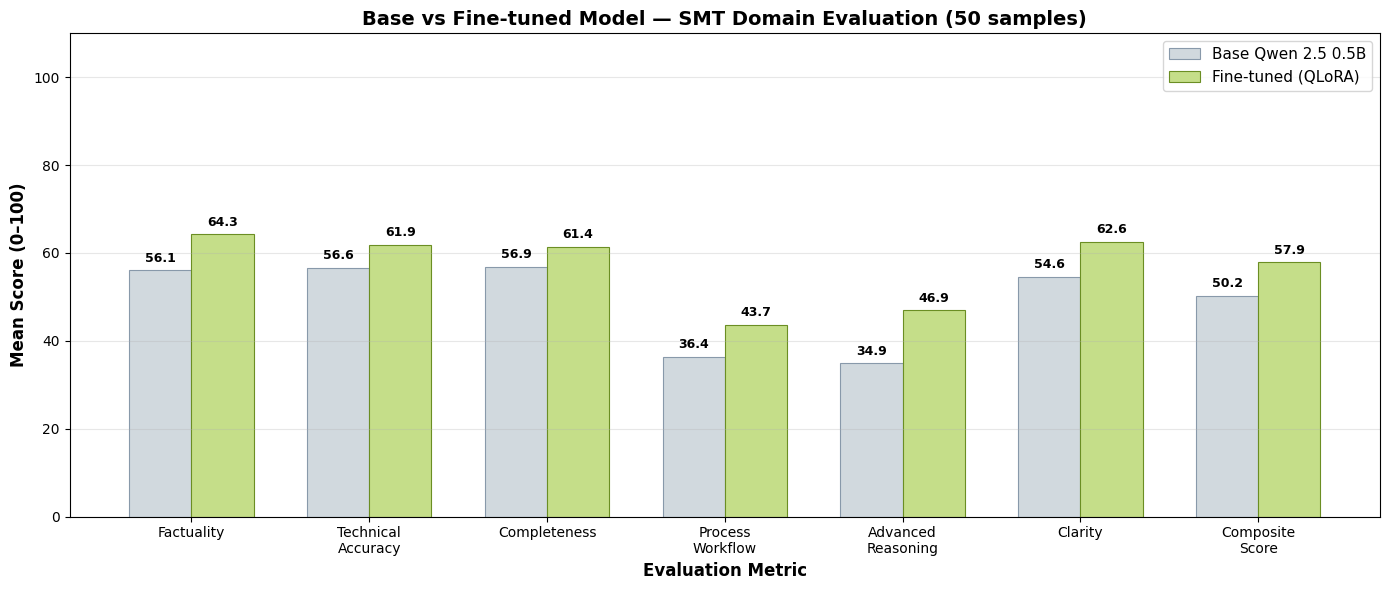

Chart saved as evaluation_comparison.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

metrics_labels = [
    "Factuality",
    "Technical\nAccuracy",
    "Completeness",
    "Process\nWorkflow",
    "Advanced\nReasoning",
    "Clarity",
    "Composite\nScore",
]

base_means = summary_df["base_mean"].values
ft_means = summary_df["finetuned_mean"].values

x = np.arange(len(metrics_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars_base = ax.bar(
    x - bar_width / 2, base_means, bar_width,
    label="Base Qwen 2.5 0.5B", color="#D1D9DE", edgecolor="#8899AA", linewidth=0.8
)
bars_ft = ax.bar(
    x + bar_width / 2, ft_means, bar_width,
    label="Fine-tuned (QLoRA)", color="#C5DE89", edgecolor="#6B8E23", linewidth=0.8
)

# Add value labels on top of each bar
for bar in bars_base:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

for bar in bars_ft:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Evaluation Metric", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean Score (0–100)", fontsize=12, fontweight="bold")
ax.set_title("Base vs Fine-tuned Model — SMT Domain Evaluation (50 samples)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=11, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print("Chart saved as evaluation_comparison.png")

## Step 8 — Per-Sample Score Details

In [16]:
# Merge per-sample scores for detailed inspection
detailed_df = results_df.copy()
for col in METRIC_NAMES + ["composite_score"]:
    detailed_df[f"base_{col}"] = base_scores_df[col].values
    detailed_df[f"ft_{col}"] = ft_scores_df[col].values
    detailed_df[f"diff_{col}"] = ft_scores_df[col].values - base_scores_df[col].values

# Show samples where fine-tuned model improved most
top_improvements = detailed_df.nlargest(5, "diff_composite_score")[
    ["instruction", "base_composite_score", "ft_composite_score", "diff_composite_score"]
]
print("Top 5 improvements (fine-tuned over base):\n")
for _, row in top_improvements.iterrows():
    print(f"  Base: {row['base_composite_score']:.1f}  →  FT: {row['ft_composite_score']:.1f}  "
          f"(+{row['diff_composite_score']:.1f})  |  {row['instruction'][:100]}...")
    print()

# Show samples where base model performed better
worse = detailed_df[detailed_df["diff_composite_score"] < 0]
print(f"\nSamples where base outperformed fine-tuned: {len(worse)} / {len(detailed_df)}")

Top 5 improvements (fine-tuned over base):

  Base: 5.7  →  FT: 62.1  (+56.4)  |  How do different brazing temperatures influence the diffusion region and microstructural composition...

  Base: 43.6  →  FT: 86.4  (+42.9)  |  What is the relationship between the addition of chromium (Cr) to eutectic Sn-Ag alloys and the obse...

  Base: 33.6  →  FT: 65.7  (+32.1)  |  What are the key mechanisms involved in the nucleation and propagation of microcracks during indenta...

  Base: 43.6  →  FT: 71.4  (+27.9)  |  How do changes in bonding temperature, bonding time, and bonding pressure affect the bonding strengt...

  Base: 47.1  →  FT: 71.4  (+24.3)  |  What are the potential impacts of the morphological features identified in the SEM analysis of the s...


Samples where base outperformed fine-tuned: 15 / 50
